In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Gaussian Naive Bayes

Naive Bayes is useful for answering the question, *given a set of measurements, what is the probability that a sample belongs to a given class?* Gaussian Naive Bayes is a variant of Naive Bayes. 

GNB creates a template for each class, as defined by the means and standard deviations of each feature within a class. Given a new measurement, a new flower, the model checks how likely it is that the flower belongs to one of the classes in order to classify it. 

Naive Bayes assumes that features are conditionally independent, meaning that, within a given class, knowing one features tells us nothing about another feature. This is a simplification that is not strictly observed in real dataset. For instance, within a flower species (class), features are highly correlated. 

For the Iris dataset, some questions that can be probed with GNB include:
- Given sepal/petal measurements, can the model correctly identify the species of flower?
- Which features have the least overlap between species, and thus are the most useful for classification?


**Assumptions:**

- Features are conditionally independent, or unrelated, within each class
- Each feature contributes equally to the outcome.
- The Gaussian part assumes that features follow a Gaussian distribution

steps: what to examine
- look for normality in pdfs

## Iris dataset

Steps for applying GNB to the dataset

1. Examine the data for 
- number of samples, features, and classes
- feature value ranges
- possible class imbalances

2. Examine feature distributions within each class for normality and class separation.

3. Split the data for training and evaluation, in order to test how well the model generalizes.

4. Train the model, using descriptive statistics
- calculate the mean and variance of every feature
- calculate the prior probability of each class, to evaluate how often each species appears.

5. Make predictions

6. Evaluate the model by examining
- accuracy score (what fraction of predictions were correct)
- the confusion matrix (where did the model make mistakes? i.e. which species were confused with one another?)
- classification report (precision, recall, F1 score for each class)

7. Examine what the model learned
- do the learned means and variances per class match intuitions from step 2?
- which features have the most spearation between classes?
- where do the Gaussian curves overlap, and does this inform us of where the model struggles?

Points for reflection: 
- were the features

In [3]:
iris = pd.read_csv("data/iris.csv")

In [4]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [7]:
setosa = iris[iris['species']=='setosa']
versicolor = iris[iris['species']=='versicolor']
virginica = iris[iris['species']=='virginica']

### Visualize the features

Visualize the four flower features and apply Shapiro-Wilk test to examine for normality. 

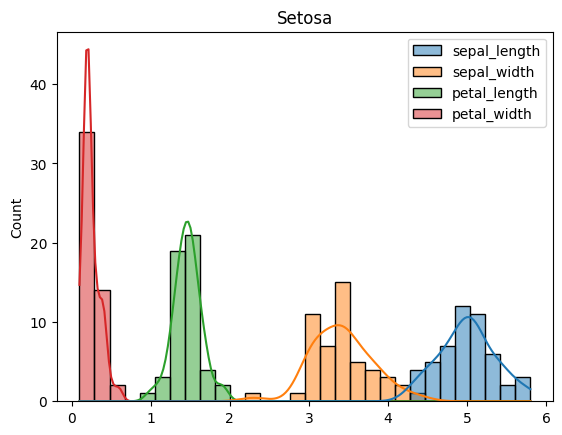

In [111]:
# plot histograms of each class
sns.histplot(iris[iris['species']=='setosa'], bins=30, kde=True).set_title('Setosa');

The Shapiro-Wilk test is a hypothesis test applied to a sample of data, where the null hypothesis is that the sample has a normal distribution. As with any hypothesis test, if the p-value is low, we reject the null hypothesis and understand that the sample is not normally distributed. 

In [18]:
from scipy import stats

In [20]:
feat = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for col in feat:
    print(col, stats.shapiro(setosa[col]))

sepal_length ShapiroResult(statistic=0.9776985497966463, pvalue=0.4595131499174635)
sepal_width ShapiroResult(statistic=0.9686918964570312, pvalue=0.20465666067561955)
petal_length ShapiroResult(statistic=0.9549461051602874, pvalue=0.05465048809971702)
petal_width ShapiroResult(statistic=0.8138167558864363, pvalue=1.852556745576707e-06)


For petal_width, setosa is not normally distributed.

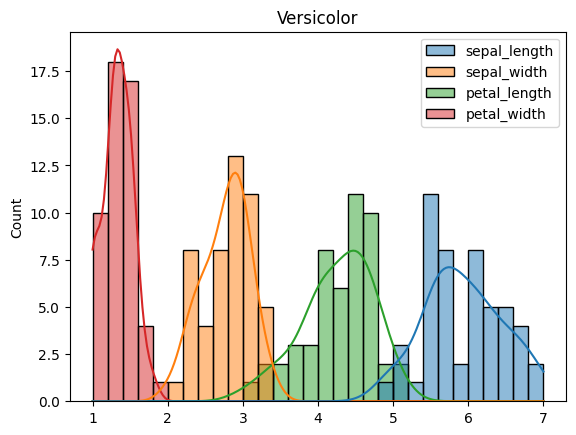

In [113]:
# plot histograms of each class
sns.histplot(versicolor, bins=30, kde=True).set_title('Versicolor');

In [26]:
for col in feat:
    print(col, stats.shapiro(versicolor[col]))

sepal_length ShapiroResult(statistic=0.9778356785897526, pvalue=0.4647370359250455)
sepal_width ShapiroResult(statistic=0.9741332819702793, pvalue=0.3379951061741208)
petal_length ShapiroResult(statistic=0.96600440254332, pvalue=0.15847783815657573)
petal_width ShapiroResult(statistic=0.9476263359557384, pvalue=0.027277803876105258)


In [29]:
for col in feat:
    print(col, stats.shapiro(virginica[col]))

sepal_length ShapiroResult(statistic=0.9711793971110263, pvalue=0.2583147461407979)
sepal_width ShapiroResult(statistic=0.9673905311257006, pvalue=0.18089604109069915)
petal_length ShapiroResult(statistic=0.9621864428612805, pvalue=0.10977536903223795)
petal_width ShapiroResult(statistic=0.9597714702389373, pvalue=0.0869541872909336)


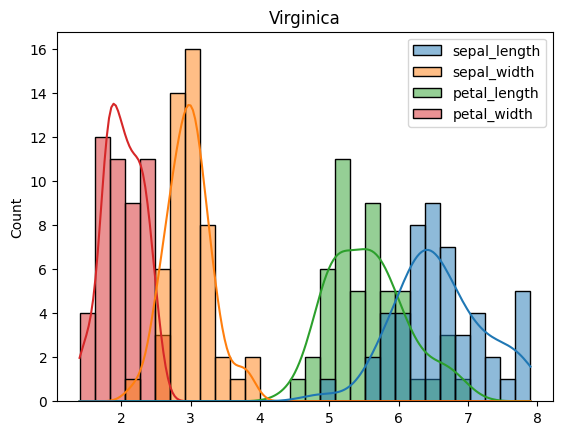

In [115]:
# plot histograms of each class
ax = sns.histplot(virginica, bins=30, kde=True)
ax.set_title('Virginica');

For versicolor and virginica, petal width is the least Gaussian, but not too bad.

Petal width (especially for the setosa class) violates normality more so than the other features, but considering the normality in the rest of the data, this should model well with a Guassian Naive Bayes classifier.

## Train the model

In [35]:
# split data
from sklearn.model_selection import train_test_split

The three species are equally balanced in the dataset, but it is not a bad idea to add a stratification parameter to the train-test split. 

In [38]:
X = iris[feat]
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# sanity check
print(X_train.shape, X_test.shape)  
print(y_train.value_counts())        
print(y_test.value_counts())      

(120, 4) (30, 4)
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


Some notes on default parameters (for iris dataset): 
- priors=\[1/3, 1/3, 1/3]; prior probabilities of the three classes

- var_smoothing=1e-9;  portion of largest variance of all features added to variances for calculation stability.

Default GuassianNB assumes balanced classes, which is appropriate here with the iris dataset, where 1/3 of the instances fall in each class. GuassianNB() calculates the variances per feature per class. If the variance is near-zero, this is a problem. var_smoothing adds a tiny amount to every variance to prevent division by zero. 

Guassian Naive Classifiers work by calculating the probability distribution function of each feature within each class, through their means and variances. 

In [45]:
# instantiate the model
gnb = GaussianNB()

In [47]:
# train the model
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Look at mean (theta) and variance (var) for each feature for each class

In [50]:
# means per class per feature
print(pd.DataFrame(gnb.theta_, columns=feat, index=gnb.classes_))

            sepal_length  sepal_width  petal_length  petal_width
setosa             4.985       3.4025        1.4800       0.2525
versicolor         5.930       2.7500        4.2525       1.3200
virginica          6.610       2.9800        5.5800       2.0400


### Can compare this to the original histograms 

Keep in mind that the original histograms were computed using the entire iris datset, whereas the training set is only 80% of the data. The means should be different, but close.

In [53]:
print(setosa['sepal_length'].mean())
print(setosa['sepal_width'].mean())
print(setosa['petal_length'].mean())
print(setosa['petal_width'].mean())

5.006
3.418
1.464
0.244


In [55]:
print(versicolor['sepal_length'].mean())
print(versicolor['sepal_width'].mean())
print(versicolor['petal_length'].mean())
print(versicolor['petal_width'].mean())

5.936
2.7700000000000005
4.26
1.3259999999999998


In [57]:
print(virginica['sepal_length'].mean())
print(virginica['sepal_width'].mean())
print(virginica['petal_length'].mean())
print(virginica['petal_width'].mean())

6.587999999999998
2.974
5.5520000000000005
2.0260000000000002


In [60]:
# variances per class per feature
print(pd.DataFrame(gnb.var_, columns=feat, index=gnb.classes_))

            sepal_length  sepal_width  petal_length  petal_width
setosa          0.092775     0.156744      0.025100     0.013494
versicolor      0.221600     0.093000      0.191494     0.034100
virginica       0.457400     0.122100      0.323600     0.070400


In [62]:
print(setosa['sepal_length'].var())
print(setosa['sepal_width'].var())
print(setosa['petal_length'].var())
print(setosa['petal_width'].var())

0.12424897959183662
0.1451795918367347
0.030106122448979603
0.011493877551020404


In [64]:
print(versicolor['sepal_length'].var())
print(versicolor['sepal_width'].var())
print(versicolor['petal_length'].var())
print(versicolor['petal_width'].var())

0.2664326530612246
0.09846938775510206
0.22081632653061237
0.039106122448979576


In [66]:
print(virginica['sepal_length'].var())
print(virginica['sepal_width'].var())
print(virginica['petal_length'].var())
print(virginica['petal_width'].var())

0.40434285714285706
0.10400408163265312
0.304587755102041
0.07543265306122447


### Evaluate the model 

In [70]:
y_pred = gnb.predict(X_test)

In [72]:
y_pred

array(['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa',
       'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor',
       'virginica', 'virginica', 'virginica', 'versicolor', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'virginica',
       'setosa', 'virginica', 'versicolor', 'virginica', 'virginica',
       'virginica', 'versicolor', 'setosa', 'virginica', 'setosa'],
      dtype='<U10')

For this balanced classifier, look at three things:
1. accuracy
2. confusion matrix
3. classification report

**Accuracy**

This is a measure of how well the model, trained on 80% of the data, is predicting on the 20% test data. This compares the actual subset of withheld data, y_test, with the predictions made by the model, y_pred. Because the dataset is balanced, this is a good measure of model performance.  

In [76]:
accuracy_score(y_test, y_pred)

0.9666666666666667

**Confusion Matrix**

This tells us, more granularly, about what the model gets right and what the model gets wrong. For a 3 class classifier, the confusion matrix looks like this:

In [80]:
cm = confusion_matrix(y_test, y_pred)

In [82]:
cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

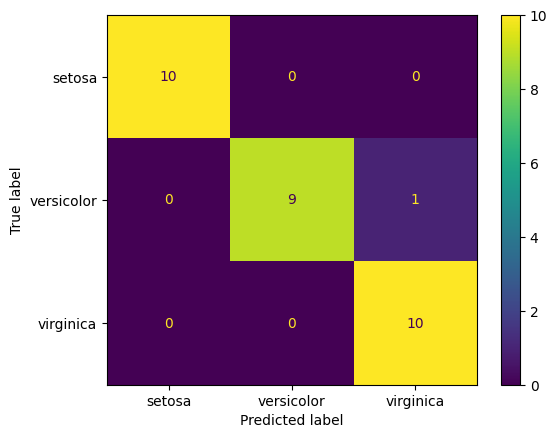

In [84]:
ConfusionMatrixDisplay(cm, display_labels=gnb.classes_).plot()

Of the actual setosa, all of them were correctly classified as setosa.

Of the actual virginica, all of them were correctly classified as virginica.

Of all the versicolor, one was misclassified as virginica.

**Classification Report**

In [90]:
print(classification_report(y_test, y_pred, target_names=gnb.classes_))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Accuracy is very high at 97%. This model does well with this data.

Precision measures the fraction of instances classified as a class that were actually in that class. A perfect model has precision = 1.0. So this model is predicting setosa and versicolor perfectly with a lower precision on virginica. 

Recall measures the fraction of class instances that were actually detected. Recall is perfect for setosa and virginica, lower for versicolor. 

The model is performing perfectly for the setosa class, with some mistakes made between the versicolor and virginica classes.

### Look at ROC-AUC curve

generate probabilities associated with predictions on test data

For each threshold with binary classes, an ROC curve asks the question, of all actual positives, how many were actually caught by the model? For a problem with multiple classes, like the iris dataset, the ROC curve is asking the question (as an example), of all actual setosa, how many were actually caught by the model. 

In [95]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

In [98]:
# get predicted probabilities
y_prob = gnb.predict_proba(X_test)

In [100]:
gnb.classes_

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [102]:
# turn multiclass data into binary for iteration over setosa (OvR conversion).
# 1 indicates setosa, 0 indicates all the rest
(y_test == 'setosa').astype(int)

38     1
127    0
57     0
93     0
42     1
56     0
22     1
20     1
147    0
84     0
107    0
141    0
104    0
51     0
7      1
49     1
14     1
69     0
63     0
138    0
10     1
140    0
58     0
134    0
132    0
77     0
75     0
18     1
116    0
28     1
Name: species, dtype: int64

In [104]:
# probabilities for setosa instances, first iteration of i=1
# this is the probability that each instance is in the class 'setosa'
y_prob[:, 1]

array([2.08454349e-20, 8.77457912e-02, 9.99999490e-01, 9.99999567e-01,
       6.67564970e-21, 6.48278636e-01, 2.07051456e-22, 3.23692231e-17,
       1.47628468e-04, 9.93265431e-01, 1.37398727e-07, 6.00049312e-08,
       3.12244544e-08, 9.53502494e-01, 8.25826380e-20, 4.24566083e-20,
       6.83540167e-21, 9.99994982e-01, 9.91306972e-01, 1.64202729e-01,
       7.82669668e-20, 3.66174477e-10, 9.93742485e-01, 4.71914424e-01,
       2.70992865e-07, 5.86622444e-02, 9.90860479e-01, 3.25722322e-16,
       9.54106100e-04, 5.83719937e-20])

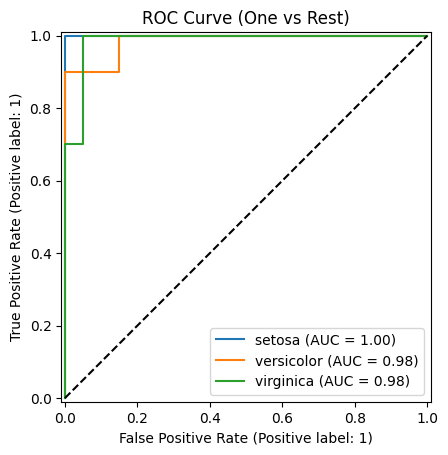

0.9899999999999999


In [106]:
# plot one curve per class
fig, ax = plt.subplots()
for i, class_name in enumerate(gnb.classes_):
    RocCurveDisplay.from_predictions(
        (y_test == class_name).astype(int),
        y_prob[:, i],
        name=class_name,
        ax=ax
    )

# create random classifier reference
ax.plot([0, 1], [0, 1], 'k--', label='random')
plt.title('ROC Curve (One vs Rest)')
plt.show()

# compute average AUC across all three OvR curves as a single summary AUC score
print(roc_auc_score(y_test, y_prob, multi_class='ovr'))

**Conclusions** 